# Player Time on Ice Exploration

In [1]:
# Dependencies

# Basics
import os
import sys
import time
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from collections import defaultdict
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path


from config import data_folder, recent_clean_db, last_game_date

# Print list of files in data/db to verify path is correct
data_db_path = Path(data_folder)
print("Files in data/db directory:")
# Path to data/db directory
print(data_db_path)
# for file in data_db_path.iterdir():
    # print(file.name)


cutoff_str = f'{last_game_date}'


Files in data/db directory:
..\data\db


In [2]:
from matplotlib import font_manager, rcParams

# Optional direct Windows font path if needed
font_path = 'C:/Windows/Fonts/Exo 2.ttf'

# Any custom locations you want to scan (e.g. project data folder)
locations = ['../data/Exo_2']

# Find and register font files
font_files = font_manager.findSystemFonts(fontpaths=locations)
for file in font_files:
    font_manager.fontManager.addfont(file)

# Font family name (as registered in the font file)
font = "Exo 2"
rcParams['font.family'] = font
rcParams['font.sans-serif'] = [font]


In [3]:
## Test color dictionary

### Team info Dictionaries
team_color_mapping = {'Air Force': ('#003087', '#8a8d8f', '#CCCCCC'),
 'Alaska': ('#236192', '#ffcd00', '#CCCCCC'),
 'Alaska Anchorage': ('#00583d', '#ffc425', '#CCCCCC'),
 'American Intl': ('#000000', '#ffb60f', '#CCCCCC'),
 "American Int'l": ('#000000', '#ffb60f', '#CCCCCC'),
 'Arizona State': ('#8c1d40', '#ffc627', '#CCCCCC'),
#  'Army': ('#d4bf91', '#b2b4b3', '#CCCCCC'), # Original - secondary is too close to primary
 'Army': ('#d4bf91', '#000000', '#CCCCCC'), # Updated - secondary changed to black
 'Augustana': ('#004b8d', '#ffdd00', '#FFFFFF'),
 'Bemidji State': ('#004d44', '#d4d67c', '#CCCCCC'),
 'Bentley': ('#1b5faa', '#88898a', '#CCCCCC'),
 'Boston College': ('#98002e', '#bc9b6a', '#CCCCCC'),
 'Boston University': ('#cc0000', '#a3011b', '#CCCCCC'),
 'Bowling Green': ('#fe5000', '#4f2c1d', '#CCCCCC'),
 'Brown': ('#4e3629', '#7c2529', '#CCCCCC'),
 'Canisius': ('#0c2340', '#ffba00', '#CCCCCC'),
 'Clarkson': ('#0d433b', '#fac922', '#CCCCCC'),
 'Colgate': ('#821019', '#e10028', '#CCCCCC'),
 'Colorado College': ('#000000', '#f2af36', '#CCCCCC'),
 'Connecticut': ('#000e2f', '#ffffff', '#CCCCCC'),
 'Cornell': ('#b31b1b', '#5e3920', '#CCCCCC'),
 'Dartmouth': ('#046a38', '#000000', '#CCCCCC'),
 'Denver': ('#8b233b', '#8b6f4b', '#CCCCCC'),
 'Ferris State': ('#ba0c2f', '#fcc917', '#CCCCCC'),
 'Harvard': ('#a41034', '#000000', '#CCCCCC'),
 'Holy Cross': ('#602d89', '#ffffff', '#CCCCCC'),
 'Lake Superior': ('#003f87', '#ffc61e', '#CCCCCC'),
 'Lindenwood': ('#B5A36A', '#101820', '#CCCCCC'),
 'Long Island': ('#69b3e7', '#ffc72c', '#CCCCCC'),
 'Maine': ('#003263', '#B0D7FF', '#AB0634'),
 'Mass Lowell': ('#003da5', '#c8102e', '#CCCCCC'),
 'Mass. Lowell': ('#003da5', '#c8102e', '#CCCCCC'),
 'Massachusetts': ('#971b2f', '#FFFFFF', '#CCCCCC'),
 'Mercyhurst': ('#07594d', '#182752', '#CCCCCC'),
 'Merrimack': ('#003768', '#fdb813', '#CCCCCC'),
 'Miami': ('#b61e2e', '#000000', '#CCCCCC'),
 'Michigan': ('#0027ac', '#ffcb05', '#CCCCCC'),
 'Michigan State': ('#18453b', '#ffffff', '#CCCCCC'),
 'Michigan Tech': ('#000000', '#ffcd00', '#CCCCCC'),
 'Minnesota': ('#7a0019', '#ffcc33', '#CCCCCC'),
 'Minnesota Duluth': ('#8e0a26', '#fab937', '#CCCCCC'),
 'Minnesota State': ('#480059', '#f7e400', '#CCCCCC'),
 'New Hampshire': ('#041e42', '#bbbcbc', '#CCCCCC'),
 'Niagara': ('#582c83', '#ffffff', '#CCCCCC'),
 'North Dakota': ('#009a44', '#aaaead', '#CCCCCC'),
 'Northeastern': ('#000000', '#e50000', '#CCCCCC'),
 'Northern Michigan': ('#095339', '#ffc425', '#CCCCCC'),
 'Notre Dame': ('#0c2340', '#c99700', '#CCCCCC'),
 'Ohio State': ('#bb0000', '#666666', '#CCCCCC'),
 'Omaha': ('#000000', '#d71920', '#636568'),
 'Penn State': ('#001E44', '#ffffff', '#CCCCCC'),
 'Princeton': ('#ff671f', '#000000', '#CCCCCC'),
 'Providence': ('#8a8d8f', '#000000', '#ffffff'),
 'Quinnipiac': ('#0c2340', '#ffb81c', '#CCCCCC'),
 'Rensselaer': ('#232020', '#ffffff', '#CCCCCC'),
 'RIT': ('#f76902', '#ffffff', '#CCCCCC'),
 'Robert Morris': ('#14234b', '#a6192e', '#CCCCCC'),
 'Sacred Heart': ('#ce1141', '#b1b3b6', '#CCCCCC'),
 'St Cloud State': ('#a10209', '#000000', '#CCCCCC'),
 'St Lawrence': ('#654134', '#e7d1a0', '#CCCCCC'),
 'St Thomas': ('#512773', '#98999b', '#CCCCCC'),
 'St. Cloud State': ('#a10209', '#000000', '#CCCCCC'),
 'St. Lawrence': ('#654134', '#e7d1a0', '#CCCCCC'),
 'St. Thomas': ('#512773', '#98999b', '#CCCCCC'),
 'Stonehill': ('#2F2975', '#ffffff', '#CCCCCC'),
 'Union': ('#9a0000', '#ffffff', '#CCCCCC'),
 'Vermont': ('#154734', '#8b5b29', '#CCCCCC'),
 'Western Michigan': ('#6c4023', '#b5a167', '#CCCCCC'),
 'Wisconsin': ('#c5050c', '#ffffff', '#CCCCCC'),
 'Yale': ('#00356b', '#ffffff', '#CCCCCC')}

In [4]:
## File Paths
folder_prefix = ''

data_folder = os.path.join(folder_prefix, '..', 'data/') # Data Folder Path
temp_folder = os.path.join(folder_prefix,'..', 'TEMP/',) # Temp Folder Path
temp_image_folder = os.path.join(folder_prefix, temp_folder, 'IMAGE/per_60_plots/') # Temp Image Folder Path
image_folder = os.path.join(folder_prefix, '..', 'images/') # Image Folder Path
logo_folder = os.path.join(folder_prefix, image_folder, 'logos/') # Logo Folder Path
conference_logo_folder = os.path.join(folder_prefix, logo_folder, 'conference') # Conference Logo Folder Path
export_folder = os.path.join(folder_prefix, image_folder, 'export/') # Export Folder Path
background_folder = os.path.join(folder_prefix, image_folder, 'background/') # Background Folder Path

# Other paths
school_info_path = os.path.join(data_folder, 'school_info', 'arena_school_info.csv') # School Info Path

In [5]:
## Load the database
conn = sqlite3.connect(recent_clean_db, isolation_level=None)

## Extract player_stats and convert TOI into seconds for easier calculations
player_stats = pd.read_sql_query("SELECT * FROM player_stats", conn)

### TOI to seconds - From MM:SS string to seconds integer
def convert_toi_to_seconds(toi_str):
    if pd.isna(toi_str):
        return None
    try:
        minutes, seconds = map(int, toi_str.split(':'))
        return minutes * 60 + seconds
    except ValueError:
        return None

player_stats['TOI'] = player_stats['TOI'].apply(convert_toi_to_seconds)

# Check Data
# print(player_stats.head())


In [6]:
#### Create a date column for each row based on the Game_ID to track change in ice time over the season
def get_date_from_game_id(game_id):
    if pd.isna(game_id):
        return None
    try:
        return str(game_id)[:10]

        # Convert to datetime object
        date_obj = datetime.strptime(game_id, '%Y-%m-%d')
        # Convert to desired format
        

    except ValueError:
        return None

# Create a new column 'Date' in the DataFrame
player_stats['Date'] = player_stats['Game_ID'].apply(get_date_from_game_id)

# Check Data
# print(player_stats.head())

## Get Line assignments from DB

In [7]:
### Call the line_chart db table to the a dataframe
line_chart = pd.read_sql_query("SELECT * FROM line_chart", conn)

# Group into F / D / G lines based on Position column into new pos_1 / pos_2 columns
# # pos_1 = F / D / G 
# Center, Left Wing, Right Wing = F
# left D, Right D = D
# Goalie = G

# pos_2 = C / L / R / D / G


## Assign positions in the new columns
def assign_positions(row):
    if row['Position'] in ['Center', 'Left Wing', 'Right Wing']:
        return pd.Series(['F', row['Position'][0]])
    elif row['Position'] in ['Left D', 'Right D']:
        return pd.Series(['D', 'D'])
    elif row['Position'] == 'Goalie':
        return pd.Series(['G', 'G'])
    else:
        return pd.Series([None, None])
line_chart[['pos_1', 'pos_2']] = line_chart.apply(assign_positions, axis=1)

# Check Data
# print(line_chart.head(20))




#### Merge Position Data in with the player_stats dataframe based on Team, Player, and Game_ID
merged_df = pd.merge(player_stats, line_chart[['Game_ID', 'Team', 'Player', 'Line', 'pos_1', 'pos_2']], on=['Game_ID', 'Team', 'Player'], how='left')

# Relabel the rows of extra skaters - they have NaN in Line pos1 / pos_2 columns - Replace with 'E'
# merged_df.loc[merged_df['pos_1'].isna(), 'pos_1'] = 'E'
# merged_df.loc[merged_df['pos_2'].isna(), 'pos_2'] = 'E'
merged_df['pos_1'].fillna('E', inplace=True)
merged_df['pos_2'].fillna('E', inplace=True)
merged_df['Line'].fillna('E', inplace=True)

# Remove any rows with TOI = 0
merged_df = merged_df[merged_df['TOI'] != 0]



C:\Users\jbanc\AppData\Local\Temp\ipykernel_10540\2609500140.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['pos_1'].fillna('E', inplace=True)
C:\Users\jbanc\AppData\Local\Temp\ipykernel_10540\2609500140.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

## Get player stats ytd table from DB Calculate Player stats normalized for per 60 minutes

In [8]:
player_ytd_stats = pd.read_sql_query("SELECT * FROM player_stats_ytd", conn)

# Check Data
print(player_ytd_stats.head())

# Calulate Goals per 60 mins using the TOI_second value, Assists per 60, Points per 60
player_ytd_stats['Goals_per_60'] = (player_ytd_stats['G'] / player_ytd_stats['TOI_sec']) * 3600
player_ytd_stats['Assists_per_60'] = (player_ytd_stats ['A'] / player_ytd_stats['TOI_sec']) * 3600
player_ytd_stats['Points_per_60'] = (player_ytd_stats['Pts'] / player_ytd_stats['TOI_sec']) * 3600
# Penalty Minutes per 60
player_ytd_stats['PIM_per_60'] = (player_ytd_stats['PIM'] / player_ytd_stats['TOI_sec']) * 3600
# Shots per 60
player_ytd_stats['Shots_per_60'] = (player_ytd_stats['Shots'] / player_ytd_stats['TOI_sec']) * 3600

# Calculate Avg TOI per Game and convert to MM:SS format
player_ytd_stats['Avg_TOI_per_Game'] = player_ytd_stats['TOI_sec'] / player_ytd_stats['Games_Played']
player_ytd_stats['Avg_TOI_per_Game'] = pd.to_datetime(player_ytd_stats['Avg_TOI_per_Game'], unit='s').dt.strftime('%M:%S')
# Rename Column To 'TOI / G'
player_ytd_stats.rename(columns={'Avg_TOI_per_Game': 'Mins/G'}, inplace=True)
# Conver TOI_sec to "TOI" MMM:SS format for display
player_ytd_stats['Total TOI'] = pd.to_datetime(player_ytd_stats['TOI_sec'], unit='s').dt.strftime('%H:%M:%S')

# Rename Games Played to GP for spacer in header
player_ytd_stats['GP'] = player_ytd_stats['Games_Played']
player_ytd_stats['S'] = player_ytd_stats['Shots']
# Rename Clean_Player to Player
player_ytd_stats.rename(columns={'Clean_Player': 'Player'}, inplace=True)


# Check Data
# print(player_ytd_stats.head())

     Clean_Player              Team  G   A  Pts  PlusMinus  Shots  TOI_sec  \
0     Aaron Pionk  Minnesota Duluth  0   5    5         -6     41    27182   
1  Aaron Reierson  Alaska Anchorage  1   2    3         -8     15     7081   
2  Aaron Schwartz        Quinnipiac  3  17   20          2     56    22912   
3   Aaron Trotter         St Thomas  0   0    0          0      0        0   
4     Abram Wiebe      North Dakota  3  12   15          1     49    31345   

   PIM  FOW  FOL  Games_Played  FO%       TOI  
0    4  0.0  0.0            26  0.0  07:33:02  
1    4  0.0  3.0             9  0.0  01:58:01  
2   10  0.0  2.0            25  0.0  06:21:52  
3    0  0.0  0.0            10  0.0  00:00:00  
4    6  0.0  0.0            26  0.0  08:42:25  


In [9]:
# player_ytd_stats

In [10]:
## Sort and display the top 20 players by Points per 60 mins
# First Filter for players with at least 60 minutes played
filtered_players = player_ytd_stats[player_ytd_stats['TOI_sec'] >= 3600]

top_20_points_per_60 = filtered_players.sort_values(by='Points_per_60', ascending=False).head(20)
# print(top_20_points_per_60)

In [11]:
# Calc and display the top 20 players by Goals per 60 mins
top_20_goals_per_60 = filtered_players.sort_values(by='Goals_per_60', ascending=False).head(20)
print(top_20_goals_per_60)

                Player              Team   G   A  Pts  PlusMinus  Shots  \
630    Hayden Stavroff         Dartmouth  20  10   30         10     71   
66         Andrew King             Brown   4   4    8          5     17   
1639      Will Horcoff          Michigan  19  11   30         10     83   
558         Finn Brink         Wisconsin   4   2    6          7     13   
901     Justin Poirier             Maine  17  11   28          1     92   
553      Felix Trudeau      Sacred Heart  20   8   28          7    101   
171       Brandon Buhr             Union  17   8   25         -4     84   
907       Kai Daniells         Princeton  13  11   24         13     65   
1664  William Whitelaw  Western Michigan  15  10   25         11     97   
59     Alton McDermott          Canisius   3   4    7          3     10   
1064    Markus Vidicek        Quinnipiac  15  10   25          7     67   
1337    Porter Martone    Michigan State  14  14   28         19     67   
102    Austin Burnevik   

## Viz code start

In [12]:
# team_df.head()

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from pathlib import Path

def lighten_color(color, amount=0.6):
    try:
        r, g, b = mcolors.to_rgb(color)
    except ValueError:
        return (0.9, 0.9, 0.9)
    return (
        (1 - amount) + amount * r,
        (1 - amount) + amount * g,
        (1 - amount) + amount * b,
    )


def create_player_leaderboard_figure(
    player_df: pd.DataFrame,
    stat_col: str = "Points_per_60",
    extra_cols=None,
    top_n: int = 15,
    min_toi_sec: int = 0,
    output_path: str | Path = "leaderboard_test.png",
    title: str | None = None,
    team_color_mapping: dict | None = None,
    column_order: list[str] | None = None,  # <--- NEW
):
    """
    Create a stylized leaderboard image of players, colored by team.
    """
    if team_color_mapping is None:
        team_color_mapping = {}

    if extra_cols is None:
        extra_cols = ["Team", "G", "A", "Pts", "Games_Played"]

    if stat_col not in player_df.columns:
        raise ValueError(f"stat_col '{stat_col}' not found in player_df.columns")

    df = player_df.copy()

    # Optional TOI filter
    if min_toi_sec:
        df = df[df["TOI_sec"] >= min_toi_sec]

    # Drop rows with no value for the chosen stat
    df = df.dropna(subset=[stat_col])

    # Sort & keep top N
    df = df.sort_values(stat_col, ascending=False).head(top_n).copy()

    if df.empty:
        raise ValueError(
            "No rows to display after filtering. "
            "Check min_toi_sec, stat_col, or your filters."
        )

    # Add Rank column at the front
    df.insert(0, "Rank", range(1, len(df) + 1))

    # ---------- column order control ----------
    if column_order is not None:
        # Use exactly the order the user specifies (dropping missing ones)
        cols = [c for c in column_order if c in df.columns]
        # Make sure stat_col is present
        if stat_col not in cols and stat_col in df.columns:
            cols.append(stat_col)
    else:
        # Original behavior
        cols = ["Rank", "Player", "Team"]
        cols += [
            c for c in extra_cols
            if c not in ("Rank", "Player", "Team") and c in df.columns
        ]
        if stat_col not in cols:
            cols.append(stat_col)
    # -----------------------------------------

    display_df = df[cols].copy()

    # Round floats
    for c in display_df.columns:
        if pd.api.types.is_float_dtype(display_df[c]):
            display_df[c] = display_df[c].round(2)

    # Nicer labels
    col_labels = [
        c.replace("_", " ").replace("per 60", "/ 60")
        for c in display_df.columns
    ]

    cell_text = display_df.values.tolist()
    n_rows, n_cols = display_df.shape


    # === Dynamic figure sizing ===
    # These control how tight or roomy the table frame feels
    base_height = 0.0         # space for title/header
    per_row_height = 0.28     # row height scaling
    per_col_width = 0.9       # column width scaling
    extra_bottom = 0.0        # space for footer annotation

    fig_height = base_height + (n_rows * per_row_height) + extra_bottom
    fig_width = max(6, n_cols * per_col_width)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    # === Build the table ===
    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc="upper center",
        cellLoc="center",
    )

    # Font
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    fig.canvas.draw()
    table.auto_set_column_width(col=list(range(n_cols)))
    table.scale(1, 1.3)

############# ORIGINAL CODE FOR TABLE CREATION #############
    # # Figure size (height based on rows; width roughly on #cols)
    # row_height = 0.4
    # fig_height = 1.5 + n_rows * row_height
    # fig_width = max(10, n_cols * 1.0)   # a bit wider base than before

    # fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    # ax.axis("off")

    # table = ax.table(
    #     cellText=cell_text,
    #     colLabels=col_labels,
    #     loc="upper center",
    #     cellLoc="center",
    # )

    # # Font
    # table.auto_set_font_size(False)
    # table.set_fontsize(12)

    # # --- auto size columns based on content ---
    # fig.canvas.draw()  # needed so text size is known
    # table.auto_set_column_width(col=list(range(n_cols)))
    # # only stretch vertically
    # table.scale(1, 1.4)
    # ------------------------------------------

    # Header styling
    for col in range(n_cols):
        cell = table[0, col]
        cell.set_facecolor("#333333")
        cell.set_text_props(color="white", weight="bold")

       # ---------- Row & cell styling ----------

    cols = list(display_df.columns)

    # Config knobs
    MAX_COLOR = "#99CCFF"       # high-end color for stat gradient (change to taste)
    ROW_BORDER_COLOR = "#BBBBBB"
    ROW_BORDER_WIDTH = 0.5

    # 1) Precompute numeric/time ranges for gradient columns
    gradient_values = {}

    # Explicit list of time-like columns to convert to total seconds
    TIME_LIKE_COLS = {"Mins/G", "Total TOI"}

    for col_name in cols:
        if col_name in ["Rank", "Player", "Team"]:
            continue

        series = display_df[col_name]
        numeric = None

        if col_name in TIME_LIKE_COLS:
            # Handle mm:ss format safely — pandas misreads these otherwise
            def mmss_to_seconds(x):
                try:
                    parts = str(x).split(":")
                    if len(parts) == 2:
                        m, s = map(float, parts)
                        return m * 60 + s
                    elif len(parts) == 3:
                        h, m, s = map(float, parts)
                        return h * 3600 + m * 60 + s
                    else:
                        return float(x)
                except Exception:
                    return None

            numeric = series.apply(mmss_to_seconds)

        else:
            # Normal numeric or fallback for time-like
            numeric_try = pd.to_numeric(series, errors="coerce")
            if numeric_try.notna().any():
                numeric = numeric_try
            else:
                td = pd.to_timedelta(series, errors="coerce")
                numeric = td.dt.total_seconds()

        if numeric is not None and numeric.notna().any():
            gradient_values[col_name] = {
                "values": numeric,
                "vmin": numeric.min(),
                "vmax": numeric.max(),
            }



    for row in range(1, n_rows + 1):
        team_name = display_df.iloc[row - 1]["Team"]
        colors = team_color_mapping.get(team_name, ("#CCCCCC", "#000000", "#CCCCCC"))

        primary = colors[0] if len(colors) > 0 and colors[0] else "#CCCCCC"
        secondary = colors[1] if len(colors) > 1 and colors[1] else "#000000"

        for col_idx, col_name in enumerate(cols):
            cell = table[row, col_idx]

            # --- team-colored columns (Rank, Player, Team) ---
            if col_name in ["Rank", "Player", "Team"]:
                cell.set_facecolor(primary)
                # Player name bold, Rank & Team normal
                # weight = "bold" if col_name == "Player" else "normal"  ## Turn on Player Name bolding
                weight = "normal" if col_name == "Player" else "normal"  ## Leave Player Name normal
                cell.set_text_props(color=secondary, weight=weight)

            # --- stat columns with gradient (including Mins/G & Total TOI) ---
            elif col_name in gradient_values:
                gv = gradient_values[col_name]
                val = gv["values"].iloc[row - 1]
                vmin, vmax = gv["vmin"], gv["vmax"]

                if pd.isna(val) or vmax == vmin:
                    bg = "white"
                else:
                    # 0 → white, 1 → MAX_COLOR
                    t = float((val - vmin) / (vmax - vmin))
                    t = max(0.0, min(1.0, t))
                    bg = lighten_color(MAX_COLOR, amount=t)

                cell.set_facecolor(bg)

                # Bold the primary stat column
                if col_name == stat_col:
                    cell.set_text_props(color="black", weight="bold")
                else:
                    cell.set_text_props(color="black", weight="normal")

            # --- other columns (non-numeric, non-special) ---
            else:
                cell.set_facecolor("white")
                cell.set_text_props(color="black")

            # --- subtle grey borders for row separation ---
            cell.set_edgecolor(ROW_BORDER_COLOR)
            cell.set_linewidth(ROW_BORDER_WIDTH)



        # === Title and footer ===
        ## SET BASED ON stat_col
        ## Designate title based on stat_col

            # Goals_per_60 = "Goals"
            # Points_per_60 = "Points"
            # Assists_per_60 = "Assists"
            # Shots_per_60 = "Shots"
            # PIM_per_60 = "Penalty Minutes"
    if stat_col == "Goals_per_60":
        if title is None:
            title = f"Top {top_n} Skaters by Goals per 60 minutes"
    elif stat_col == "Points_per_60":
        if title is None:
            title = f"Top {top_n} Skaters by Points per 60 minutes"
    elif stat_col == "Assists_per_60":
        if title is None:
            title = f"Top {top_n} Skaters by Assists per 60 minutes"
    elif stat_col == "Shots_per_60":
        if title is None:
            title = f"Top {top_n} Skaters by Shots per 60 minutes"
    elif stat_col == "PIM_per_60":
        if title is None:
            title = f"Top {top_n} Skaters by Penalty Minutes per 60 minutes"


    ax.set_title(
        title,
        fontsize=18,
        pad=10,          # less vertical padding
        weight="bold",
    )

    # Data source annotation (centered under chart)
    footer_text = (
        f"Data Source: College Hockey News | Includes all games through {cutoff_str}"
    )

    fig.text(
        0.5, 0.001,       # centered near bottom
        footer_text,
        ha='center', va='bottom',
        fontsize=12, color='black', alpha=0.8,
    )

    # === Tighten layout and export ===
    fig.subplots_adjust(top=0.88, bottom=0.10, left=0.03, right=0.97)
    output_path = Path(output_path)
    fig.savefig(output_path, dpi=200, bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)

    return output_path, display_df


In [14]:
player_ytd_stats.columns

Index(['Player', 'Team', 'G', 'A', 'Pts', 'PlusMinus', 'Shots', 'TOI_sec',
       'PIM', 'FOW', 'FOL', 'Games_Played', 'FO%', 'TOI', 'Goals_per_60',
       'Assists_per_60', 'Points_per_60', 'PIM_per_60', 'Shots_per_60',
       'Mins/G', 'Total TOI', 'GP', 'S'],
      dtype='object')

In [15]:
## Designate title based on stat_col

Goals_per_60 = "Goals"
Points_per_60 = "Points"
Assists_per_60 = "Assists"
Shots_per_60 = "Shots"
PIM_per_60 = "Penalty Minutes"
# Mins/G = "Time on Ice per Game"

#### Top 30 Goals per 60

In [16]:
column_order = [
    "Rank",
    "Player",
    "Team",
    # "Points_per_60",
    "Goals_per_60",
    "Mins/G",
    "GP",
    "G",
    "A",
    "Pts",
    "PIM",
    "S",
    
    # "PIM_per_60",
    
    # "Goals_per_60",
    # "Shots_per_60",
    
    # "Total TOI",
]

stat_col = "Goals_per_60"
top_n = 30


output_path, top_table = create_player_leaderboard_figure(
    player_df=player_ytd_stats,
    stat_col=stat_col,  # uses your variable
    extra_cols=["Mins/G", "Total TOI", "Games_Played", "G", "A", "Pts"],
    top_n=top_n,
    min_toi_sec=1800,
    output_path=f"{temp_image_folder}state_leaderboard_{stat_col}_top{top_n}_{cutoff_str}.png",
    team_color_mapping=team_color_mapping,
    column_order=column_order,
)
print(f"Leaderboard image saved to: {temp_image_folder}{output_path}")



Leaderboard image saved to: ..\TEMP/IMAGE/per_60_plots/..\TEMP\IMAGE\per_60_plots\state_leaderboard_Goals_per_60_top30_ January 25, 2026.png


#### Top 30 Points per 60

In [17]:
column_order = [
    "Rank",
    "Player",
    "Team",
    "Points_per_60",
    # "Goals_per_60",
    "Mins/G",
    "GP",
    "G",
    "A",
    "Pts",
    "PIM",
    "S",
    
    # "PIM_per_60",
    
    # "Goals_per_60",
    # "Shots_per_60",
    
    # "Total TOI",
]

stat_col = "Points_per_60"
top_n = 30


output_path, top_table = create_player_leaderboard_figure(
    player_df=player_ytd_stats,
    stat_col=stat_col,  # uses your variable
    extra_cols=["Mins/G", "Total TOI", "Games_Played", "G", "A", "Pts"],
    top_n=top_n,
    min_toi_sec=1800,
    output_path=f"{temp_image_folder}state_leaderboard_{stat_col}_top{top_n}_{cutoff_str}.png",
    team_color_mapping=team_color_mapping,
    column_order=column_order,
)
print(f"Leaderboard image saved to: {temp_image_folder}{output_path}")



Leaderboard image saved to: ..\TEMP/IMAGE/per_60_plots/..\TEMP\IMAGE\per_60_plots\state_leaderboard_Points_per_60_top30_ January 25, 2026.png


#### Top 30 Shots per 60

In [18]:
column_order = [
    "Rank",
    "Player",
    "Team",
    "Shots_per_60",
    "Goals_per_60",
    "Mins/G",
    "GP",
    "G",
    "A",
    "Pts",
    "PIM",
    "S",
    
    # "PIM_per_60",
    
    # "Goals_per_60",
    # "Shots_per_60",
    
    # "Total TOI",
]

stat_col = "Shots_per_60"
top_n = 30


output_path, top_table = create_player_leaderboard_figure(
    player_df=player_ytd_stats,
    stat_col=stat_col,  # uses your variable
    extra_cols=["Mins/G", "Total TOI", "Games_Played", "G", "A", "Pts"],
    top_n=top_n,
    min_toi_sec=1800,
    output_path=f"{temp_image_folder}state_leaderboard_{stat_col}_top{top_n}_{cutoff_str}.png",
    team_color_mapping=team_color_mapping,
    column_order=column_order,
)
print(f"Leaderboard image saved to: {temp_image_folder}{output_path}")



Leaderboard image saved to: ..\TEMP/IMAGE/per_60_plots/..\TEMP\IMAGE\per_60_plots\state_leaderboard_Shots_per_60_top30_ January 25, 2026.png


#### Top 30 PIM per 60

In [19]:
column_order = [
    "Rank",
    "Player",
    "Team",
    "PIM_per_60",
    # "Goals_per_60",
    "Mins/G",
    "GP",
    "G",
    "A",
    "Pts",
    "PIM",
    "S",
    
    # "PIM_per_60",
    
    # "Goals_per_60",
    # "Shots_per_60",
    
    # "Total TOI",
]

stat_col = "PIM_per_60"
top_n = 30


output_path, top_table = create_player_leaderboard_figure(
    player_df=player_ytd_stats,
    stat_col=stat_col,  # uses your variable
    extra_cols=["Mins/G", "Total TOI", "Games_Played", "G", "A", "Pts"],
    top_n=top_n,
    min_toi_sec=1800,
    output_path=f"{temp_image_folder}state_leaderboard_{stat_col}_top{top_n}_{cutoff_str}.png",
    team_color_mapping=team_color_mapping,
    column_order=column_order,
)
print(f"Leaderboard image saved to: {temp_image_folder}{output_path}")



Leaderboard image saved to: ..\TEMP/IMAGE/per_60_plots/..\TEMP\IMAGE\per_60_plots\state_leaderboard_PIM_per_60_top30_ January 25, 2026.png


#### Top 30 TOI/G

FileNotFoundError: [Errno 2] No such file or directory: '..\\TEMP\\IMAGE\\per_60_plots\\state_leaderboard_Mins\\G_top30_ January 25, 2026.png'

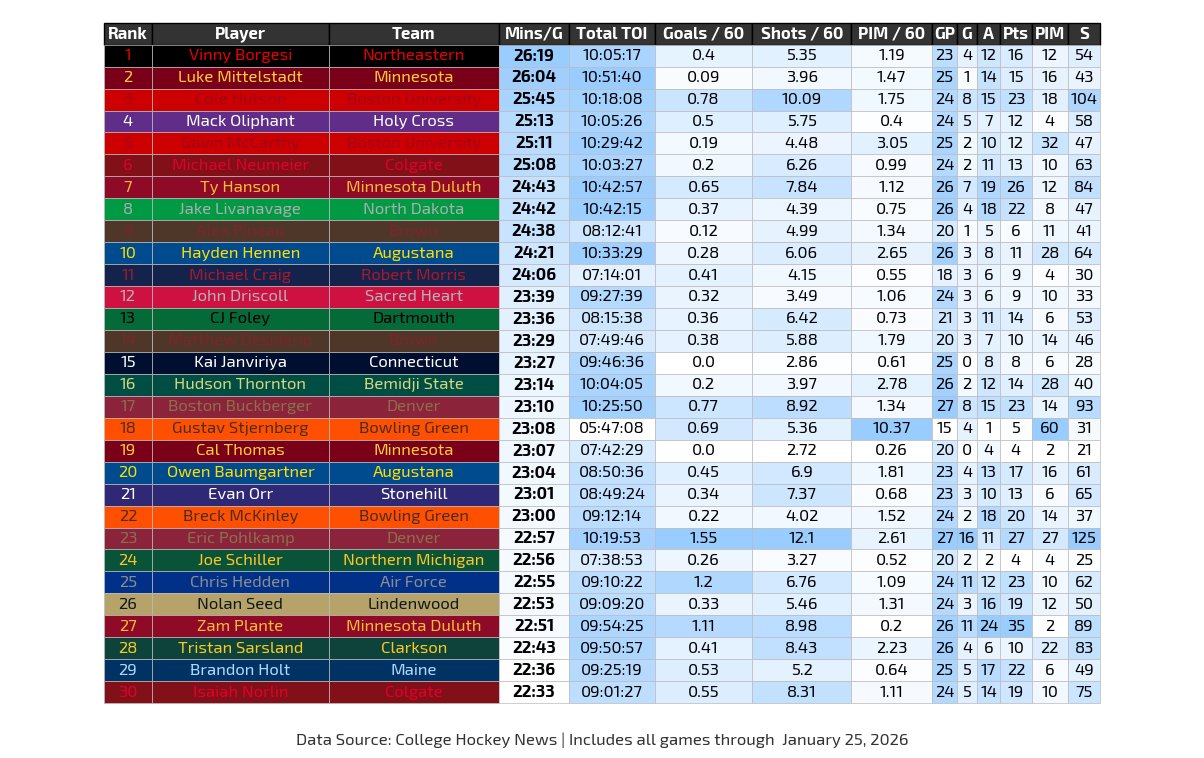

In [20]:
column_order = [
    "Rank",
    "Player",
    "Team",
    # "PIM_per_60",
    
    "Mins/G",
    "Total TOI",
    "Goals_per_60",
    "Shots_per_60",
    "PIM_per_60",
    "GP",
    "G",
    "A",
    "Pts",
    "PIM",
    "S",
    
    
    
    # "Goals_per_60",
    
    
    
]

stat_col = "Mins/G"
top_n = 30


output_path, top_table = create_player_leaderboard_figure(
    player_df=player_ytd_stats,
    stat_col=stat_col,  # uses your variable
    extra_cols=["Mins/G", "Total TOI", "Games_Played", "G", "A", "Pts"],
    top_n=top_n,
    min_toi_sec=1800,
    output_path=f"{temp_image_folder}state_leaderboard_{stat_col}_top{top_n}_{cutoff_str}.png",
    team_color_mapping=team_color_mapping,
    column_order=column_order,
)
print(f"Leaderboard image saved to: {temp_image_folder}{output_path}")



In [ ]:
print(player_ytd_stats["Mins/G"].head())
print(player_ytd_stats["Mins/G"].dtype)


0    17:54
1    14:39
2    00:00
3    18:40
4    20:08
Name: Mins/G, dtype: object
object


In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)